# Step 15: Seasonal Naive Baseline

This step evaluates a seasonal naive forecast across smooth, erratic,
intermittent and lumpy demand.

The forecast for each item-store series is its sales value from 7 days
earlier.

Five expanding walk-forward folds are created from the 1,941 unique
dates. Each fold uses a 28-day test window. All 800 series share the same
training and test dates.

WRMSSE is calculated using the 12 M5 aggregation levels. The hierarchy is
rebuilt separately within each demand type so that smooth, erratic,
intermittent and lumpy demand receive separate scores.

MAE is calculated at the item-store-day level as the secondary metric.

In [1]:
import gc
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

from sklearn.model_selection import TimeSeriesSplit

np.random.seed(42)

project_root = Path("..")

processed_data_path = project_root / "data" / "processed"
model_results_path = project_root / "outputs" / "model_results"
tables_path = project_root / "outputs" / "tables" / "step15"
figures_path = project_root / "outputs" / "figures" / "step15"

model_results_path.mkdir(parents=True, exist_ok=True)
tables_path.mkdir(parents=True, exist_ok=True)
figures_path.mkdir(parents=True, exist_ok=True)

input_file = (
    processed_data_path
    / "modelling_dataset.parquet"
)

print("Input:", input_file)

Input: ..\data\processed\modelling_dataset.parquet


In [20]:
model_data = pd.read_parquet(input_file)

model_data["date"] = pd.to_datetime(
    model_data["date"]
)

model_data = model_data.sort_values(
    ["id", "date"]
).reset_index(drop=True)

demand_type_order = [
    "smooth",
    "erratic",
    "intermittent",
    "lumpy"
]

model_data["demand_type"] = pd.Categorical(
    model_data["demand_type"],
    categories=demand_type_order,
    ordered=True
)

print("Rows:", len(model_data))
print("Series:", model_data["id"].nunique())
print(
    "Date range:",
    model_data["date"].min(),
    "to",
    model_data["date"].max()
)

print()
print(
    model_data[
        ["id", "demand_type"]
    ]
    .drop_duplicates()["demand_type"]
    .value_counts(sort=False)
)

Rows: 1552800
Series: 800
Date range: 2011-01-29 00:00:00 to 2016-05-22 00:00:00

demand_type
smooth          200
erratic         200
intermittent    200
lumpy           200
Name: count, dtype: int64


In [21]:
unique_dates = np.array(
    sorted(model_data["date"].unique())
)

number_of_folds = 5
test_window_days = 28

time_split = TimeSeriesSplit(
    n_splits=number_of_folds,
    test_size=test_window_days,
    gap=0
)

fold_records = []
fold_date_indices = []

date_index_input = np.arange(
    len(unique_dates)
).reshape(-1, 1)

for fold, (
    train_date_indices,
    test_date_indices
) in enumerate(
    time_split.split(date_index_input),
    start=1
):
    train_dates = unique_dates[
        train_date_indices
    ]
    
    test_dates = unique_dates[
        test_date_indices
    ]
    
    fold_date_indices.append({
        "fold": fold,
        "train_dates": train_dates,
        "test_dates": test_dates
    })
    
    fold_records.append({
        "fold": fold,
        "train_start": pd.Timestamp(
            train_dates[0]
        ),
        "train_end": pd.Timestamp(
            train_dates[-1]
        ),
        "train_days": len(train_dates),
        "test_start": pd.Timestamp(
            test_dates[0]
        ),
        "test_end": pd.Timestamp(
            test_dates[-1]
        ),
        "test_days": len(test_dates)
    })

fold_schedule = pd.DataFrame(
    fold_records
)

fold_schedule

,fold,train_start,train_end,train_days,test_start,test_end,test_days
0,1,2011-01-29,2016-01-03,1801,2016-01-04,2016-01-31,28
1,2,2011-01-29,2016-01-31,1829,2016-02-01,2016-02-28,28
2,3,2011-01-29,2016-02-28,1857,2016-02-29,2016-03-27,28
3,4,2011-01-29,2016-03-27,1885,2016-03-28,2016-04-24,28
4,5,2011-01-29,2016-04-24,1913,2016-04-25,2016-05-22,28


In [4]:
fold_schedule["train_before_test"] = (
    fold_schedule["train_end"]
    < fold_schedule["test_start"]
)

fold_schedule["correct_test_length"] = (
    fold_schedule["test_days"]
    == 28
)

all_test_dates = np.concatenate([
    fold_info["test_dates"]
    for fold_info in fold_date_indices
])

print("Unique dates:", len(unique_dates))
print("Number of folds:", len(fold_schedule))

print(
    "All training periods end before testing:",
    fold_schedule[
        "train_before_test"
    ].all()
)

print(
    "All test windows contain 28 days:",
    fold_schedule[
        "correct_test_length"
    ].all()
)

print(
    "Total test dates:",
    len(all_test_dates)
)

print(
    "Unique test dates:",
    len(np.unique(all_test_dates))
)

print(
    "Test windows do not overlap:",
    len(all_test_dates)
    == len(np.unique(all_test_dates))
)

Unique dates: 1941
Number of folds: 5
All training periods end before testing: True
All test windows contain 28 days: True
Total test dates: 140
Unique test dates: 140
Test windows do not overlap: True


In [22]:
fold_schedule.to_csv(
    tables_path
    / "step15_fold_schedule.csv",
    index=False
)

In [23]:
hierarchy_levels = [
    (
        "L1_Total",
        []
    ),
    (
        "L2_State",
        ["state_id"]
    ),
    (
        "L3_Store",
        ["store_id"]
    ),
    (
        "L4_Category",
        ["cat_id"]
    ),
    (
        "L5_Department",
        ["dept_id"]
    ),
    (
        "L6_State_Category",
        ["state_id", "cat_id"]
    ),
    (
        "L7_State_Department",
        ["state_id", "dept_id"]
    ),
    (
        "L8_Store_Category",
        ["store_id", "cat_id"]
    ),
    (
        "L9_Store_Department",
        ["store_id", "dept_id"]
    ),
    (
        "L10_Item",
        ["item_id"]
    ),
    (
        "L11_Item_State",
        ["item_id", "state_id"]
    ),
    (
        "L12_Item_Store",
        ["item_id", "store_id"]
    )
]

print(
    "Hierarchy levels:",
    len(hierarchy_levels)
)

for level_name, keys in hierarchy_levels:
    print(level_name, keys)

Hierarchy levels: 12
L1_Total []
L2_State ['state_id']
L3_Store ['store_id']
L4_Category ['cat_id']
L5_Department ['dept_id']
L6_State_Category ['state_id', 'cat_id']
L7_State_Department ['state_id', 'dept_id']
L8_Store_Category ['store_id', 'cat_id']
L9_Store_Department ['store_id', 'dept_id']
L10_Item ['item_id']
L11_Item_State ['item_id', 'state_id']
L12_Item_Store ['item_id', 'store_id']


In [24]:
def create_series_key(
    data,
    grouping_columns
):
    return (
        data[grouping_columns]
        .astype("string")
        .agg("|".join, axis=1)
    )

In [25]:
def aggregate_daily_values(
    data,
    grouping_columns,
    value_columns
):
    if len(grouping_columns) == 0:
        aggregated = (
            data
            .groupby(
                "date",
                as_index=False,
                sort=True
            )[value_columns]
            .sum()
        )
        
        aggregated["series_key"] = "Total"
    
    else:
        aggregated = (
            data
            .groupby(
                grouping_columns + ["date"],
                observed=True,
                as_index=False,
                sort=True
            )[value_columns]
            .sum()
        )
        
        aggregated["series_key"] = (
            create_series_key(
                aggregated,
                grouping_columns
            )
        )
    
    return aggregated[
        ["series_key", "date"]
        + value_columns
    ]

In [26]:
def aggregate_dollar_weights(
    data,
    grouping_columns
):
    if len(grouping_columns) == 0:
        return pd.DataFrame({
            "series_key": ["Total"],
            "raw_weight": [
                data["dollar_sales"].sum()
            ]
        })
    
    aggregated = (
        data
        .groupby(
            grouping_columns,
            observed=True,
            as_index=False,
            sort=True
        )["dollar_sales"]
        .sum()
        .rename(
            columns={
                "dollar_sales": "raw_weight"
            }
        )
    )
    
    aggregated["series_key"] = (
        create_series_key(
            aggregated,
            grouping_columns
        )
    )
    
    return aggregated[
        ["series_key", "raw_weight"]
    ]

In [27]:
def calculate_m5_scale(values):
    values = np.asarray(
        values,
        dtype=np.float64
    )
    
    non_zero_positions = np.flatnonzero(
        values != 0
    )
    
    if len(non_zero_positions) == 0:
        return np.nan
    
    first_non_zero = non_zero_positions[0]
    
    trimmed_values = values[
        first_non_zero:
    ]
    
    if len(trimmed_values) < 2:
        return np.nan
    
    squared_differences = np.diff(
        trimmed_values
    ) ** 2
    
    scale = squared_differences.mean()
    
    if not np.isfinite(scale):
        return np.nan
    
    if scale <= 0:
        return np.nan
    
    return float(scale)

In [28]:
def evaluate_type_wrmsse(
    train_data,
    test_data,
    demand_type,
    fold
):
    train_end = train_data[
        "date"
    ].max()
    
    weight_start = (
        train_end
        - pd.Timedelta(days=27)
    )
    
    weight_window = train_data.loc[
        train_data["date"].between(
            weight_start,
            train_end
        )
    ].copy()
    
    missing_price_with_sales = (
        (
            weight_window["sales"] > 0
        )
        & (
            weight_window[
                "sell_price"
            ].isna()
        )
    ).sum()
    
    if missing_price_with_sales > 0:
        raise ValueError(
            f"{missing_price_with_sales} "
            "positive-sales rows have "
            "missing prices in the "
            "weight window."
        )
    
    weight_window["dollar_sales"] = (
        weight_window["sales"]
        .astype("float64")
        * weight_window[
            "sell_price"
        ]
        .fillna(0)
        .astype("float64")
    )
    
    level_diagnostics = []
    
    for level_name, grouping_columns in hierarchy_levels:
        train_level = aggregate_daily_values(
            train_data,
            grouping_columns,
            ["sales"]
        )
        
        test_level = aggregate_daily_values(
            test_data,
            grouping_columns,
            [
                "sales",
                "naive_forecast"
            ]
        )
        
        level_weights = aggregate_dollar_weights(
            weight_window,
            grouping_columns
        )
        
        scale_table = (
            train_level
            .sort_values(
                ["series_key", "date"]
            )
            .groupby(
                "series_key",
                sort=False
            )["sales"]
            .apply(calculate_m5_scale)
            .rename("scale")
            .reset_index()
        )
        
        test_level["squared_error"] = (
            test_level["sales"]
            - test_level[
                "naive_forecast"
            ]
        ) ** 2
        
        test_level["absolute_error"] = (
            test_level["sales"]
            - test_level[
                "naive_forecast"
            ]
        ).abs()
        
        error_table = (
            test_level
            .groupby(
                "series_key",
                as_index=False,
                sort=False
            )
            .agg(
                test_mse=(
                    "squared_error",
                    "mean"
                ),
                test_mae=(
                    "absolute_error",
                    "mean"
                ),
                test_days=(
                    "date",
                    "nunique"
                )
            )
        )
        
        level_result = (
            error_table
            .merge(
                scale_table,
                on="series_key",
                how="left",
                validate="one_to_one"
            )
            .merge(
                level_weights,
                on="series_key",
                how="left",
                validate="one_to_one"
            )
        )
        
        invalid_positive_weight_scale = (
            level_result["scale"].isna()
            & level_result[
                "raw_weight"
            ].gt(0)
        )
        
        if invalid_positive_weight_scale.any():
            invalid_count = int(
                invalid_positive_weight_scale.sum()
            )
            
            raise ValueError(
                f"{demand_type}, Fold {fold}, "
                f"{level_name}: {invalid_count} "
                "positive-weight series have "
                "an invalid scale."
            )
        
        level_result["rmsse"] = np.where(
            level_result["scale"].gt(0),
            np.sqrt(
                level_result["test_mse"]
                / level_result["scale"]
            ),
            0.0
        )
        
        level_result["fold"] = fold
        level_result[
            "demand_type"
        ] = demand_type
        level_result["level"] = level_name
        
        level_diagnostics.append(
            level_result
        )
        
        del train_level
        del test_level
        del scale_table
        del error_table
        del level_result
        
        gc.collect()
    
    diagnostics = pd.concat(
        level_diagnostics,
        ignore_index=True
    )
    
    total_raw_weight = diagnostics[
        "raw_weight"
    ].sum()
    
    if total_raw_weight <= 0:
        raise ValueError(
            f"{demand_type}, Fold {fold}: "
            "total dollar-sales weight is zero."
        )
    
    diagnostics["weight"] = (
        diagnostics["raw_weight"]
        / total_raw_weight
    )
    
    diagnostics["weighted_rmsse"] = (
        diagnostics["weight"]
        * diagnostics["rmsse"]
    )
    
    wrmsse = diagnostics[
        "weighted_rmsse"
    ].sum()
    
    level_summary = (
        diagnostics
        .groupby(
            [
                "fold",
                "demand_type",
                "level"
            ],
            as_index=False,
            observed=True
        )
        .agg(
            hierarchy_series=(
                "series_key",
                "count"
            ),
            level_weight_share=(
                "weight",
                "sum"
            ),
            wrmsse_contribution=(
                "weighted_rmsse",
                "sum"
            ),
            invalid_scale_count=(
                "scale",
                lambda values: (
                    values.isna()
                ).sum()
            ),
            minimum_test_days=(
                "test_days",
                "min"
            ),
            maximum_test_days=(
                "test_days",
                "max"
            )
        )
    )
    
    level_summary["level_wrmsse"] = (
        level_summary[
            "wrmsse_contribution"
        ]
        / level_summary[
            "level_weight_share"
        ]
    )
    
    return (
        float(wrmsse),
        diagnostics,
        level_summary
    )

In [41]:
def create_seasonal_naive_forecast(
    train_data,
    test_data,
    train_end,
    test_start
):
    """
    Repeat the final 7 observed training days
    across the complete 28-day test horizon.
    """
    
    template_start = (
        train_end
        - pd.Timedelta(days=6)
    )
    
    last_training_week = train_data.loc[
        train_data["date"].between(
            template_start,
            train_end
        ),
        [
            "id",
            "date",
            "sales"
        ]
    ].copy()
    
    rows_per_series = (
        last_training_week
        .groupby(
            "id",
            observed=True
        )
        .size()
    )
    
    if not rows_per_series.eq(7).all():
        invalid_series = int(
            (~rows_per_series.eq(7)).sum()
        )
        
        raise ValueError(
            f"{invalid_series} series do not "
            "contain exactly 7 training dates."
        )
    
    last_training_week[
        "seasonal_position"
    ] = (
        last_training_week["date"]
        - template_start
    ).dt.days.astype("int8")
    
    forecast_template = (
        last_training_week
        .rename(
            columns={
                "date": "forecast_source_date",
                "sales": "naive_forecast"
            }
        )[
            [
                "id",
                "seasonal_position",
                "forecast_source_date",
                "naive_forecast"
            ]
        ]
    )
    
    forecast_data = test_data.copy()
    
    forecast_data["horizon_day"] = (
        (
            forecast_data["date"]
            - test_start
        ).dt.days
        + 1
    ).astype("int8")
    
    forecast_data[
        "seasonal_position"
    ] = (
        (
            forecast_data["horizon_day"]
            - 1
        )
        % 7
    ).astype("int8")
    
    forecast_data = forecast_data.merge(
        forecast_template,
        on=[
            "id",
            "seasonal_position"
        ],
        how="left",
        validate="many_to_one",
        sort=False
    )
    
    missing_forecasts = (
        forecast_data[
            "naive_forecast"
        ].isna().sum()
    )
    
    future_source_rows = (
        forecast_data[
            "forecast_source_date"
        ]
        > train_end
    ).sum()
    
    if missing_forecasts > 0:
        raise ValueError(
            f"{missing_forecasts} seasonal "
            "naive forecasts are missing."
        )
    
    if future_source_rows > 0:
        raise ValueError(
            f"{future_source_rows} forecasts "
            "use data after the training end."
        )
    
    forecast_data[
        "naive_forecast"
    ] = forecast_data[
        "naive_forecast"
    ].astype("float64")
    
    return forecast_data

In [42]:
fold_result_records = []
prediction_parts = []
hierarchy_diagnostic_parts = []
level_summary_parts = []

for fold_info in fold_date_indices:
    fold = fold_info["fold"]
    train_dates = fold_info["train_dates"]
    test_dates = fold_info["test_dates"]
    
    train_end = pd.Timestamp(
        train_dates[-1]
    )
    
    test_start = pd.Timestamp(
        test_dates[0]
    )
    
    test_end = pd.Timestamp(
        test_dates[-1]
    )
    
    train_fold = model_data.loc[
        model_data["date"] <= train_end
    ].copy()
    
    raw_test_fold = model_data.loc[
        model_data["date"].between(
            test_start,
            test_end
        )
    ].copy()
    
    test_fold = create_seasonal_naive_forecast(
        train_data=train_fold,
        test_data=raw_test_fold,
        train_end=train_end,
        test_start=test_start
    )
    
    print(
        f"\nFold {fold}: "
        f"{test_start.date()} to "
        f"{test_end.date()}"
    )
    
    for demand_type in demand_type_order:
        train_type = train_fold.loc[
            train_fold[
                "demand_type"
            ] == demand_type
        ].copy()
        
        test_type = test_fold.loc[
            test_fold[
                "demand_type"
            ] == demand_type
        ].copy()
        
        bottom_series_count = (
            test_type["id"].nunique()
        )
        
        bottom_test_rows = len(
            test_type
        )
        
        bottom_test_days = (
            test_type["date"].nunique()
        )
        
        if bottom_series_count != 200:
            raise ValueError(
                f"{demand_type}, Fold {fold}: "
                f"expected 200 series, found "
                f"{bottom_series_count}."
            )
        
        if bottom_test_rows != 5600:
            raise ValueError(
                f"{demand_type}, Fold {fold}: "
                f"expected 5,600 rows, found "
                f"{bottom_test_rows}."
            )
        
        naive_mae = (
            test_type["sales"]
            - test_type[
                "naive_forecast"
            ]
        ).abs().mean()
        
        (
            naive_wrmsse,
            hierarchy_diagnostics,
            level_summary
        ) = evaluate_type_wrmsse(
            train_data=train_type,
            test_data=test_type,
            demand_type=demand_type,
            fold=fold
        )
        
        fold_result_records.append({
            "fold": fold,
            "demand_type": demand_type,
            "train_end": train_end,
            "test_start": test_start,
            "test_end": test_end,
            "number_of_series": (
                bottom_series_count
            ),
            "test_rows": bottom_test_rows,
            "test_days": bottom_test_days,
            "naive_wrmsse": (
                naive_wrmsse
            ),
            "naive_mae": float(
                naive_mae
            )
        })
        
        prediction_part = test_type[
            [
                "id",
                "item_id",
                "store_id",
                "state_id",
                "cat_id",
                "dept_id",
                "demand_type",
                "date",
                "horizon_day",
                "forecast_source_date",
                "sales",
                "naive_forecast"
            ]
        ].copy()
        
        prediction_part["fold"] = fold
        prediction_part["train_end"] = train_end
        
        prediction_part[
            "absolute_error"
        ] = (
            prediction_part["sales"]
            - prediction_part[
                "naive_forecast"
            ]
        ).abs()
        
        prediction_part[
            "squared_error"
        ] = (
            prediction_part["sales"]
            - prediction_part[
                "naive_forecast"
            ]
        ) ** 2
        
        prediction_parts.append(
            prediction_part
        )
        
        hierarchy_diagnostic_parts.append(
            hierarchy_diagnostics
        )
        
        level_summary_parts.append(
            level_summary
        )
        
        print(
            f"{demand_type}: "
            f"WRMSSE={naive_wrmsse:.4f}, "
            f"MAE={naive_mae:.4f}"
        )
        
        del train_type
        del test_type
        del hierarchy_diagnostics
        del level_summary
        del prediction_part
        
        gc.collect()
    
    del train_fold
    del raw_test_fold
    del test_fold
    
    gc.collect()


Fold 1: 2016-01-04 to 2016-01-31
smooth: WRMSSE=0.9394, MAE=3.6455
erratic: WRMSSE=1.2000, MAE=4.7909
intermittent: WRMSSE=0.9947, MAE=0.7148
lumpy: WRMSSE=1.3338, MAE=1.7695

Fold 2: 2016-02-01 to 2016-02-28
smooth: WRMSSE=0.8636, MAE=3.3189
erratic: WRMSSE=1.0220, MAE=4.5393
intermittent: WRMSSE=1.0272, MAE=0.7439
lumpy: WRMSSE=1.3143, MAE=1.8334

Fold 3: 2016-02-29 to 2016-03-27
smooth: WRMSSE=0.7424, MAE=3.1891
erratic: WRMSSE=0.8296, MAE=4.4593
intermittent: WRMSSE=1.5583, MAE=1.1130
lumpy: WRMSSE=1.2462, MAE=1.7009

Fold 4: 2016-03-28 to 2016-04-24
smooth: WRMSSE=0.7668, MAE=3.3880
erratic: WRMSSE=0.8372, MAE=4.4146
intermittent: WRMSSE=1.1513, MAE=0.9243
lumpy: WRMSSE=1.1687, MAE=1.7339

Fold 5: 2016-04-25 to 2016-05-22
smooth: WRMSSE=0.7197, MAE=3.1336
erratic: WRMSSE=0.8610, MAE=4.0484
intermittent: WRMSSE=1.3468, MAE=0.9738
lumpy: WRMSSE=1.2316, MAE=1.7970


In [44]:
naive_fold_results = pd.DataFrame(
    fold_result_records
)

naive_predictions = pd.concat(
    prediction_parts,
    ignore_index=True
)

hierarchy_diagnostics = pd.concat(
    hierarchy_diagnostic_parts,
    ignore_index=True
)

naive_level_results = pd.concat(
    level_summary_parts,
    ignore_index=True
)

naive_fold_results = (
    naive_fold_results
    .sort_values(
        ["fold", "demand_type"]
    )
    .reset_index(drop=True)
)

naive_fold_results

,fold,demand_type,train_end,test_start,test_end,number_of_series,test_rows,test_days,naive_wrmsse,naive_mae
0,1,erratic,2016-01-03,2016-01-04,2016-01-31,200,5600,28,1.200028,4.790893
1,1,intermittent,2016-01-03,2016-01-04,2016-01-31,200,5600,28,0.994666,0.714821
2,1,lumpy,2016-01-03,2016-01-04,2016-01-31,200,5600,28,1.333758,1.769464
3,1,smooth,2016-01-03,2016-01-04,2016-01-31,200,5600,28,0.939399,3.645536
4,2,erratic,2016-01-31,2016-02-01,2016-02-28,200,5600,28,1.022020,4.539286
5,2,intermittent,2016-01-31,2016-02-01,2016-02-28,200,5600,28,1.027196,0.743929
6,2,lumpy,2016-01-31,2016-02-01,2016-02-28,200,5600,28,1.314270,1.833393
7,2,smooth,2016-01-31,2016-02-01,2016-02-28,200,5600,28,0.863560,3.318929
8,3,erratic,2016-02-28,2016-02-29,2016-03-27,200,5600,28,0.829640,4.459286
9,3,intermittent,2016-02-28,2016-02-29,2016-03-27,200,5600,28,1.558262,1.113036


In [45]:
forecast_sources_after_training = (
    naive_predictions[
        "forecast_source_date"
    ]
    > naive_predictions[
        "train_end"
    ]
).sum()

source_dates_per_series_fold = (
    naive_predictions
    .groupby(
        ["fold", "id"],
        observed=True
    )["forecast_source_date"]
    .nunique()
)

forecast_values_per_position = (
    naive_predictions
    .assign(
        seasonal_position=(
            naive_predictions[
                "horizon_day"
            ] - 1
        ) % 7
    )
    .groupby(
        [
            "fold",
            "id",
            "seasonal_position"
        ],
        observed=True
    )["naive_forecast"]
    .nunique()
)

print(
    "Forecast sources after training end:",
    forecast_sources_after_training
)

print(
    "Every series uses exactly 7 source dates:",
    source_dates_per_series_fold
    .eq(7)
    .all()
)

print(
    "Forecast repeats consistently every 7 days:",
    forecast_values_per_position
    .eq(1)
    .all()
)

print(
    "Minimum horizon day:",
    naive_predictions[
        "horizon_day"
    ].min()
)

print(
    "Maximum horizon day:",
    naive_predictions[
        "horizon_day"
    ].max()
)

Forecast sources after training end: 0
Every series uses exactly 7 source dates: True
Forecast repeats consistently every 7 days: True
Minimum horizon day: 1
Maximum horizon day: 28


In [46]:
naive_summary_detailed = (
    naive_fold_results
    .groupby(
        "demand_type",
        observed=True
    )
    .agg(
        Naive_WRMSSE=(
            "naive_wrmsse",
            "mean"
        ),
        WRMSSE_SD=(
            "naive_wrmsse",
            "std"
        ),
        Naive_MAE=(
            "naive_mae",
            "mean"
        ),
        MAE_SD=(
            "naive_mae",
            "std"
        ),
        Number_of_Series=(
            "number_of_series",
            "first"
        )
    )
    .reindex(demand_type_order)
    .round(4)
)

naive_summary_detailed

,Naive_WRMSSE,WRMSSE_SD,Naive_MAE,MAE_SD,Number_of_Series
demand_type,,,,,
smooth,0.8064,0.0924,3.3350,0.2008,200
erratic,0.9500,0.1603,4.4505,0.2678,200
intermittent,1.2156,0.2362,0.8940,0.1657,200
lumpy,1.2589,0.0665,1.7669,0.0519,200


In [47]:
naive_summary = naive_summary_detailed[
    [
        "Naive_WRMSSE",
        "Naive_MAE",
        "Number_of_Series"
    ]
].copy()

naive_summary

,Naive_WRMSSE,Naive_MAE,Number_of_Series
demand_type,,,
smooth,0.8064,3.3350,200
erratic,0.9500,4.4505,200
intermittent,1.2156,0.8940,200
lumpy,1.2589,1.7669,200


In [48]:
expected_prediction_rows = (
    800
    * 5
    * 28
)

prediction_rows_by_fold_type = (
    naive_predictions
    .groupby(
        ["fold", "demand_type"],
        observed=True
    )
    .size()
    .rename("rows")
    .reset_index()
)

print(
    "Expected prediction rows:",
    expected_prediction_rows
)

print(
    "Actual prediction rows:",
    len(naive_predictions)
)

print(
    "Prediction row match:",
    len(naive_predictions)
    == expected_prediction_rows
)

print(
    "Every fold-type has 5,600 rows:",
    prediction_rows_by_fold_type[
        "rows"
    ].eq(5600).all()
)

print(
    "Missing forecasts:",
    naive_predictions[
        "naive_forecast"
    ].isna().sum()
)

print(
    "Negative forecasts:",
    (
        naive_predictions[
            "naive_forecast"
        ] < 0
    ).sum()
)

Expected prediction rows: 112000
Actual prediction rows: 112000
Prediction row match: True
Every fold-type has 5,600 rows: True
Missing forecasts: 0
Negative forecasts: 0


In [49]:
expected_level_weight = (
    1 / 12
)

naive_level_results[
    "weight_difference"
] = (
    naive_level_results[
        "level_weight_share"
    ]
    - expected_level_weight
).abs()

weight_sum_by_fold_type = (
    naive_level_results
    .groupby(
        ["fold", "demand_type"],
        observed=True
    )["level_weight_share"]
    .sum()
)

print(
    "Expected weight per level:",
    round(
        expected_level_weight,
        6
    )
)

print(
    "Maximum level-weight difference:",
    naive_level_results[
        "weight_difference"
    ].max()
)

print(
    "Every fold-type weight sum equals 1:",
    np.allclose(
        weight_sum_by_fold_type,
        1.0
    )
)

print(
    "All hierarchy series have 28 test days:",
    (
        naive_level_results[
            "minimum_test_days"
        ].eq(28).all()
        and
        naive_level_results[
            "maximum_test_days"
        ].eq(28).all()
    )
)

print(
    "Invalid positive-weight scales:",
    hierarchy_diagnostics.loc[
        hierarchy_diagnostics[
            "raw_weight"
        ].gt(0),
        "scale"
    ].isna().sum()
)

Expected weight per level: 0.083333
Maximum level-weight difference: 1.3877787807814457e-17
Every fold-type weight sum equals 1: True
All hierarchy series have 28 test days: True
Invalid positive-weight scales: 0


In [50]:
print(
    "Fold results:",
    len(naive_fold_results)
)

print(
    "Expected fold results:",
    5 * 4
)

print(
    "All WRMSSE values finite:",
    np.isfinite(
        naive_fold_results[
            "naive_wrmsse"
        ]
    ).all()
)

print(
    "All MAE values finite:",
    np.isfinite(
        naive_fold_results[
            "naive_mae"
        ]
    ).all()
)

print(
    "All WRMSSE values non-negative:",
    naive_fold_results[
        "naive_wrmsse"
    ].ge(0).all()
)

print(
    "All MAE values non-negative:",
    naive_fold_results[
        "naive_mae"
    ].ge(0).all()
)

print(
    "All demand types have five folds:",
    naive_fold_results
    .groupby(
        "demand_type",
        observed=True
    )["fold"]
    .nunique()
    .eq(5)
    .all()
)

Fold results: 20
Expected fold results: 20
All WRMSSE values finite: True
All MAE values finite: True
All WRMSSE values non-negative: True
All MAE values non-negative: True
All demand types have five folds: True


In [51]:
naive_fold_results.to_csv(
    model_results_path
    / "step15_naive_fold_results.csv",
    index=False
)

naive_summary.to_csv(
    model_results_path
    / "step15_naive_summary_by_demand_type.csv"
)

naive_summary_detailed.to_csv(
    model_results_path
    / "step15_naive_summary_detailed.csv"
)

naive_level_results.to_csv(
    model_results_path
    / "step15_naive_results_by_hierarchy_level.csv",
    index=False
)

naive_predictions.to_parquet(
    model_results_path
    / "step15_naive_predictions.parquet",
    index=False,
    engine="pyarrow",
    compression="zstd"
)

print("Step 15 result files saved.")

Step 15 result files saved.


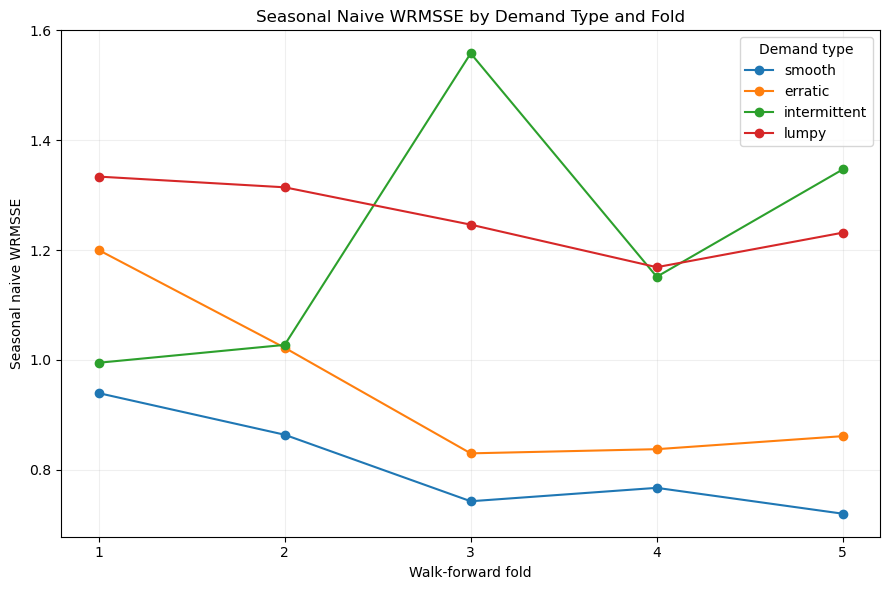

Saved: ..\outputs\figures\step15\step15_naive_wrmsse_by_fold.png


In [52]:
wrmsse_fold_plot = (
    naive_fold_results
    .pivot(
        index="fold",
        columns="demand_type",
        values="naive_wrmsse"
    )
    .reindex(
        columns=demand_type_order
    )
)

fig, ax = plt.subplots(
    figsize=(9, 6)
)

wrmsse_fold_plot.plot(
    marker="o",
    ax=ax
)

ax.set_xlabel("Walk-forward fold")
ax.set_ylabel("Seasonal naive WRMSSE")
ax.set_title(
    "Seasonal Naive WRMSSE by Demand Type and Fold"
)

ax.set_xticks(
    range(1, 6)
)

ax.grid(
    alpha=0.2
)

ax.legend(
    title="Demand type"
)

figure_file = (
    figures_path
    / "step15_naive_wrmsse_by_fold.png"
)

fig.tight_layout()

fig.savefig(
    figure_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure_file)

**Figure 15.1:** Seasonal naive WRMSSE across 5 walk-forward folds.

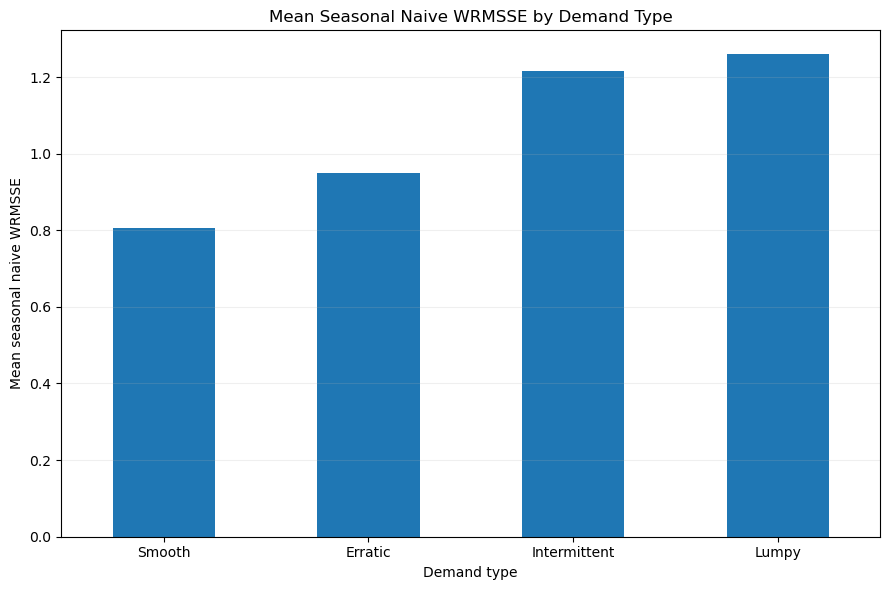

Saved: ..\outputs\figures\step15\step15_mean_naive_wrmsse_by_demand_type.png


In [53]:
fig, ax = plt.subplots(
    figsize=(9, 6)
)

naive_summary[
    "Naive_WRMSSE"
].plot(
    kind="bar",
    ax=ax
)

ax.set_xlabel("Demand type")
ax.set_ylabel("Mean seasonal naive WRMSSE")
ax.set_title(
    "Mean Seasonal Naive WRMSSE by Demand Type"
)

ax.set_xticklabels(
    [
        demand_type.title()
        for demand_type in demand_type_order
    ],
    rotation=0
)

ax.grid(
    axis="y",
    alpha=0.2
)

figure_file = (
    figures_path
    / "step15_mean_naive_wrmsse_by_demand_type.png"
)

fig.tight_layout()

fig.savefig(
    figure_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure_file)

**Figure 15.2:** Mean seasonal naive WRMSSE by demand type.

In [57]:
validation_summary = pd.DataFrame([
    {
        "check": "Five folds created",
        "actual": len(fold_schedule),
        "expected": 5,
        "passed": len(fold_schedule) == 5
    },
    {
        "check": "Test days per fold",
        "actual": (
            fold_schedule[
                "test_days"
            ].min()
        ),
        "expected": 28,
        "passed": (
            fold_schedule[
                "test_days"
            ].eq(28).all()
        )
    },
    {
        "check": "Prediction rows",
        "actual": len(
            naive_predictions
        ),
        "expected": 112000,
        "passed": (
            len(naive_predictions)
            == 112000
        )
    },
    {
        "check": "Missing forecasts",
        "actual": (
            naive_predictions[
                "naive_forecast"
            ].isna().sum()
        ),
        "expected": 0,
        "passed": (
            naive_predictions[
                "naive_forecast"
            ].isna().sum()
            == 0
        )
    },
    {
        "check": "Forecast sources after training end",
        "actual": (
            forecast_sources_after_training
        ),
        "expected": 0,
        "passed": (
            forecast_sources_after_training
            == 0
        )
    },
    {
        "check": "Seven source dates per series-fold",
        "actual": (
            source_dates_per_series_fold
            .min()
        ),
        "expected": 7,
        "passed": (
            source_dates_per_series_fold
            .eq(7)
            .all()
        )
    },
    {
        "check": "Seven-day forecast pattern repeats",
        "actual": (
            forecast_values_per_position
            .max()
        ),
        "expected": 1,
        "passed": (
            forecast_values_per_position
            .eq(1)
            .all()
        )
    },
    {
        "check": "Forecast horizon begins at day 1",
        "actual": (
            naive_predictions[
                "horizon_day"
            ].min()
        ),
        "expected": 1,
        "passed": (
            naive_predictions[
                "horizon_day"
            ].min()
            == 1
        )
    },
    {
        "check": "Forecast horizon ends at day 28",
        "actual": (
            naive_predictions[
                "horizon_day"
            ].max()
        ),
        "expected": 28,
        "passed": (
            naive_predictions[
                "horizon_day"
            ].max()
            == 28
        )
    },
    {
        "check": "Fold-type row count",
        "actual": (
            prediction_rows_by_fold_type[
                "rows"
            ].min()
        ),
        "expected": 5600,
        "passed": (
            prediction_rows_by_fold_type[
                "rows"
            ].eq(5600)
            .all()
        )
    },
    {
        "check": "WRMSSE values finite",
        "actual": (
            np.isfinite(
                naive_fold_results[
                    "naive_wrmsse"
                ]
            ).all()
        ),
        "expected": True,
        "passed": (
            np.isfinite(
                naive_fold_results[
                    "naive_wrmsse"
                ]
            ).all()
        )
    },
    {
        "check": "MAE values finite",
        "actual": (
            np.isfinite(
                naive_fold_results[
                    "naive_mae"
                ]
            ).all()
        ),
        "expected": True,
        "passed": (
            np.isfinite(
                naive_fold_results[
                    "naive_mae"
                ]
            ).all()
        )
    },
    {
        "check": "Hierarchy weights sum to 1",
        "actual": (
            weight_sum_by_fold_type
            .min()
        ),
        "expected": 1.0,
        "passed": np.allclose(
            weight_sum_by_fold_type,
            1.0
        )
    },
    {
        "check": "Hierarchy test days",
        "actual": (
            naive_level_results[
                "minimum_test_days"
            ].min()
        ),
        "expected": 28,
        "passed": (
            naive_level_results[
                "minimum_test_days"
            ].eq(28).all()
            and
            naive_level_results[
                "maximum_test_days"
            ].eq(28).all()
        )
    }
])

validation_summary

,check,actual,expected,passed
0,Five folds created,5,5,True
1,Test days per fold,28,28,True
2,Prediction rows,112000,112000,True
3,Missing forecasts,0,0,True
4,Forecast sources after training end,0,0,True
5,Seven source dates per series-fold,7,7,True
6,Seven-day forecast pattern repeats,1,1,True
7,Forecast horizon begins at day 1,1,1,True
8,Forecast horizon ends at day 28,28,28,True
9,Fold-type row count,5600,5600,True


In [58]:
validation_summary.to_csv(
    tables_path
    / "step15_validation_summary.csv",
    index=False
)

print(
    "All Step 15 checks passed:",
    validation_summary[
        "passed"
    ].all()
)

All Step 15 checks passed: True


In [59]:
saved_prediction_file = (
    model_results_path
    / "step15_naive_predictions.parquet"
)

prediction_metadata = pq.ParquetFile(
    saved_prediction_file
)

print(
    "Saved prediction rows:",
    prediction_metadata.metadata.num_rows
)

print(
    "Saved prediction row match:",
    prediction_metadata.metadata.num_rows
    == 112000
)

print(
    "Saved prediction file size MB:",
    round(
        saved_prediction_file.stat().st_size
        / (1024 ** 2),
        3
    )
)

Saved prediction rows: 112000
Saved prediction row match: True
Saved prediction file size MB: 0.261


## Step 15 Interpretation

### 15.1 Walk-forward validation and metric checks

The seasonal naive baseline was evaluated using 5 expanding walk-forward folds. Each fold contained a 28-day test window, giving 140 non-overlapping test dates from 4 January 2016 to 22 May 2016.

Each demand type contributed 200 item-store series and 5,600 test observations per fold. Across 5 folds and 4 demand types, the evaluation produced 112,000 forecasts.

The seasonal naive forecast repeated the final 7 observed training days across each 28-day test horizon. All 112,000 forecasts used source dates on or before the relevant training end date, and 0 forecasts used sales observed inside the test period.

Every series used exactly 7 training dates to generate its forecast, and the same weekly pattern was repeated 4 times across horizon days 1 to 28. There were 0 missing forecasts and 0 negative forecasts.

WRMSSE was calculated across all 12 M5 hierarchy levels within each demand type. Each level received a weight share of approximately 0.083333, all fold-type weight totals equalled 1.0, and 0 positive-weight hierarchy series had an invalid scaling denominator.

### 15.2 Seasonal naive performance by demand type

Smooth demand produced the lowest mean WRMSSE at 0.8064. Erratic demand followed with a mean WRMSSE of 0.9500.

Intermittent demand recorded a mean WRMSSE of 1.2156, while lumpy demand produced the highest mean WRMSSE at 1.2589. The lumpy score was 56.1% higher than the smooth score, and the intermittent score was 50.7% higher than the smooth score.

The ordering was therefore clear at the demand-type level:

1. Smooth: 0.8064
2. Erratic: 0.9500
3. Intermittent: 1.2156
4. Lumpy: 1.2589

The 7-day seasonal pattern was most effective for smooth demand, where sales occurred on 85.618% of observed days in the selected subset. It was less effective for intermittent demand, where the mean zero-sales rate reached 72.436%.

For lumpy demand, the model had to predict series with a mean zero-sales rate of 59.889% and a mean CV² of 0.721. Repeating the previous weekly pattern could not reliably anticipate irregular non-zero sales quantities.

### 15.3 Performance across the 5 folds

Smooth demand achieved the lowest WRMSSE in all 5 folds. Its score ranged from 0.7197 in Fold 5 to 0.9394 in Fold 1, with a standard deviation of 0.0924.

Erratic demand ranged from 0.8296 in Fold 3 to 1.2000 in Fold 1. Its standard deviation of 0.1603 was higher than the smooth value of 0.0924, showing that the weekly baseline was less stable when non-zero sales quantities varied more sharply.

Intermittent demand was the least stable group. Its WRMSSE ranged from 0.9947 in Fold 1 to 1.5583 in Fold 3, producing the largest standard deviation at 0.2362.

The intermittent score increased from 1.0272 in Fold 2 to 1.5583 in Fold 3, a difference of 0.5311. This shows that a baseline that appears acceptable during one 28-day period can fail during the next period when demand occurrences shift.

Lumpy demand was consistently difficult but comparatively stable. Its WRMSSE remained between 1.1687 and 1.3338, with the smallest standard deviation at 0.0665.

The low lumpy standard deviation does not indicate good forecasts. It shows that the seasonal naive model produced consistently high scaled error across all 5 folds.

### 15.4 Difference between MAE and WRMSSE

Erratic demand produced the highest mean MAE at 4.4505, while smooth demand produced a mean MAE of 3.3350. Intermittent demand recorded the lowest mean MAE at 0.8940, followed by lumpy demand at 1.7669.

The MAE ordering differs from the WRMSSE ordering because the 4 demand types operate at different sales volumes. In Step 13, erratic series recorded median daily sales of 5.630 units, while intermittent series recorded only 0.347 units.

A forecast of zero will often have a small absolute error for intermittent demand because 72.436% of its observations contain zero sales. However, WRMSSE adjusts the errors using each series’ historical scale and dollar-sales weight.

Intermittent demand therefore combined the lowest MAE of 0.8940 with the second-highest WRMSSE of 1.2156. The low MAE does not mean that the baseline forecasted intermittent demand well.

This difference confirms why MAE remains a secondary interpretation metric. WRMSSE is the primary measure because it accounts for scale and commercial weighting across the 12 M5 hierarchy levels.

### 15.5 Answer to RQ1

RQ1 asks how seasonal naive performance varies across smooth, erratic, intermittent and lumpy demand.

The answer from the 5 walk-forward folds is that baseline accuracy depends strongly on demand type. Smooth demand achieved the lowest mean WRMSSE at 0.8064, followed by erratic demand at 0.9500.

Performance weakened for sparse demand. Intermittent demand produced a mean WRMSSE of 1.2156, and lumpy demand produced 1.2589.

Intermittent demand also had the largest fold-to-fold standard deviation at 0.2362. Lumpy demand had the smallest standard deviation at 0.0665 but remained above 1.1687 in every fold.

The baseline results establish the comparison point for Step 16. XGBoost must improve on 0.8064 for smooth, 0.9500 for erratic, 1.2156 for intermittent and 1.2589 for lumpy demand to outperform the seasonal naive model within each demand type.


### Surprise Log

The main surprise in Step 15 was that intermittent demand produced the lowest MAE at 0.8940 but the second-highest WRMSSE at 1.2156.

The difference occurred because intermittent demand had a mean zero-sales rate of 72.436% and median daily sales of only 0.347 units. Frequent zero observations kept the absolute error small, but the scaled and weighted metric showed that the forecasts were weak relative to each series’ demand history.

A second unexpected result was that lumpy demand had the smallest WRMSSE standard deviation at 0.0665. This did not represent stable accuracy. Its score remained between 1.1687 and 1.3338 across all 5 folds, meaning that the baseline was consistently poor rather than inconsistently poor.


# Step 15A: WRMSSE Denominator Audit

This audit verifies that every RMSSE scaling denominator was calculated
using only observations available before the relevant 28-day test window.

For each of the 5 folds, 4 demand types and 12 M5 hierarchy levels, I
recalculate the scaling denominator directly from the training data and
compare it with the value stored during the seasonal naive evaluation.

The denominator begins at the first non-zero observation of each
aggregated series and excludes all test-period observations.

In [60]:
required_objects = [
    "model_data",
    "fold_date_indices",
    "demand_type_order",
    "hierarchy_levels",
    "hierarchy_diagnostics",
    "aggregate_daily_values",
    "calculate_m5_scale",
    "tables_path",
    "validation_summary"
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

print(
    "Missing required objects:",
    missing_objects
)

if missing_objects:
    raise NameError(
        "Run the earlier Step 15 cells first. "
        f"Missing objects: {missing_objects}"
    )

print(
    "Required Step 15 objects available:",
    len(missing_objects) == 0
)

Missing required objects: []
Required Step 15 objects available: True


In [64]:
expected_diagnostic_columns = [
    "fold",
    "demand_type",
    "level",
    "series_key",
    "scale",
    "raw_weight"
]

missing_diagnostic_columns = [
    column
    for column in expected_diagnostic_columns
    if column not in hierarchy_diagnostics.columns
]

print(
    "Hierarchy diagnostic rows:",
    len(hierarchy_diagnostics)
)

print(
    "Missing diagnostic columns:",
    missing_diagnostic_columns
)

print(
    "Folds found:",
    sorted(
        hierarchy_diagnostics[
            "fold"
        ].unique()
    )
)

print(
    "Demand types found:",
    hierarchy_diagnostics[
        "demand_type"
    ].unique().tolist()
)

print(
    "Hierarchy levels found:",
    hierarchy_diagnostics[
        "level"
    ].nunique()
)

if missing_diagnostic_columns:
    raise ValueError(
        "The hierarchy diagnostic table is "
        "missing required columns."
    )

Hierarchy diagnostic rows: 13450
Missing diagnostic columns: []
Folds found: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Demand types found: ['smooth', 'erratic', 'intermittent', 'lumpy']
Hierarchy levels found: 12


In [63]:
wrmsse_scale_audit_records = []

for fold_info in fold_date_indices:
    fold = fold_info["fold"]
    
    train_start = pd.Timestamp(
        fold_info["train_dates"][0]
    )
    
    train_end = pd.Timestamp(
        fold_info["train_dates"][-1]
    )
    
    test_start = pd.Timestamp(
        fold_info["test_dates"][0]
    )
    
    test_end = pd.Timestamp(
        fold_info["test_dates"][-1]
    )
    
    for demand_type in demand_type_order:
        train_type = model_data.loc[
            (
                model_data["date"]
                >= train_start
            )
            & (
                model_data["date"]
                <= train_end
            )
            & (
                model_data[
                    "demand_type"
                ] == demand_type
            )
        ].copy()
        
        if len(train_type) == 0:
            raise ValueError(
                f"No training rows for Fold {fold}, "
                f"{demand_type}."
            )
        
        for (
            level_name,
            grouping_columns
        ) in hierarchy_levels:
            
            manual_train_level = (
                aggregate_daily_values(
                    train_type,
                    grouping_columns,
                    ["sales"]
                )
            )
            
            manual_scales = (
                manual_train_level
                .sort_values(
                    [
                        "series_key",
                        "date"
                    ]
                )
                .groupby(
                    "series_key",
                    sort=False
                )["sales"]
                .apply(
                    calculate_m5_scale
                )
                .rename(
                    "manual_training_scale"
                )
                .reset_index()
            )
            
            stored_scales = (
                hierarchy_diagnostics.loc[
                    (
                        hierarchy_diagnostics[
                            "fold"
                        ] == fold
                    )
                    & (
                        hierarchy_diagnostics[
                            "demand_type"
                        ] == demand_type
                    )
                    & (
                        hierarchy_diagnostics[
                            "level"
                        ] == level_name
                    ),
                    [
                        "series_key",
                        "scale",
                        "raw_weight"
                    ]
                ]
                .rename(
                    columns={
                        "scale":
                            "stored_wrmsse_scale"
                    }
                )
                .copy()
            )
            
            scale_comparison = (
                manual_scales
                .merge(
                    stored_scales,
                    on="series_key",
                    how="outer",
                    validate="one_to_one",
                    indicator=True
                )
            )
            
            manual_missing_pattern = (
                scale_comparison[
                    "manual_training_scale"
                ].isna()
            )
            
            stored_missing_pattern = (
                scale_comparison[
                    "stored_wrmsse_scale"
                ].isna()
            )
            
            missing_patterns_match = (
                manual_missing_pattern
                .eq(
                    stored_missing_pattern
                )
                .all()
            )
            
            numeric_scale_mask = (
                scale_comparison[
                    "manual_training_scale"
                ].notna()
                & scale_comparison[
                    "stored_wrmsse_scale"
                ].notna()
            )
            
            numeric_scale_differences = (
                scale_comparison.loc[
                    numeric_scale_mask,
                    "manual_training_scale"
                ]
                - scale_comparison.loc[
                    numeric_scale_mask,
                    "stored_wrmsse_scale"
                ]
            ).abs()
            
            if len(
                numeric_scale_differences
            ) > 0:
                maximum_scale_difference = float(
                    numeric_scale_differences.max()
                )
            else:
                maximum_scale_difference = 0.0
            
            all_numeric_scales_match = (
                np.allclose(
                    scale_comparison.loc[
                        numeric_scale_mask,
                        "manual_training_scale"
                    ],
                    scale_comparison.loc[
                        numeric_scale_mask,
                        "stored_wrmsse_scale"
                    ],
                    rtol=1e-12,
                    atol=1e-12,
                    equal_nan=True
                )
            )
            
            all_keys_match = (
                scale_comparison[
                    "_merge"
                ].eq("both").all()
            )
            
            all_scales_match = (
                all_keys_match
                and missing_patterns_match
                and all_numeric_scales_match
            )
            
            positive_weight_invalid_scales = int(
                (
                    scale_comparison[
                        "stored_wrmsse_scale"
                    ].isna()
                    & scale_comparison[
                        "raw_weight"
                    ].fillna(0)
                    .gt(0)
                ).sum()
            )
            
            wrmsse_scale_audit_records.append({
                "fold": fold,
                "demand_type": demand_type,
                "level": level_name,
                "grouping_columns": (
                    "|".join(
                        grouping_columns
                    )
                    if grouping_columns
                    else "Total"
                ),
                "training_start": train_start,
                "training_end": train_end,
                "test_start": test_start,
                "test_end": test_end,
                "training_end_before_test": (
                    train_end < test_start
                ),
                "manual_scale_rows": len(
                    manual_scales
                ),
                "stored_scale_rows": len(
                    stored_scales
                ),
                "all_series_keys_match": (
                    all_keys_match
                ),
                "missing_scale_patterns_match": (
                    missing_patterns_match
                ),
                "all_scales_match": (
                    all_scales_match
                ),
                "maximum_scale_difference": (
                    maximum_scale_difference
                ),
                "positive_weight_invalid_scales": (
                    positive_weight_invalid_scales
                )
            })
        
        del train_type

wrmsse_scale_audit = pd.DataFrame(
    wrmsse_scale_audit_records
)

print(
    "Audit rows:",
    len(wrmsse_scale_audit)
)

wrmsse_scale_audit.head(12)

Audit rows: 240


,fold,demand_type,level,grouping_columns,training_start,training_end,test_start,test_end,training_end_before_test,manual_scale_rows,stored_scale_rows,all_series_keys_match,missing_scale_patterns_match,all_scales_match,maximum_scale_difference,positive_weight_invalid_scales
0,1,smooth,L1_Total,Total,2011-01-29,2016-01-03,2016-01-04,2016-01-31,True,1,1,True,True,True,0.0,0
1,1,smooth,L2_State,state_id,2011-01-29,2016-01-03,2016-01-04,2016-01-31,True,3,3,True,True,True,0.0,0
2,1,smooth,L3_Store,store_id,2011-01-29,2016-01-03,2016-01-04,2016-01-31,True,10,10,True,True,True,0.0,0
3,1,smooth,L4_Category,cat_id,2011-01-29,2016-01-03,2016-01-04,2016-01-31,True,3,3,True,True,True,0.0,0
4,1,smooth,L5_Department,dept_id,2011-01-29,2016-01-03,2016-01-04,2016-01-31,True,5,5,True,True,True,0.0,0
5,1,smooth,L6_State_Category,state_id|cat_id,2011-01-29,2016-01-03,2016-01-04,2016-01-31,True,9,9,True,True,True,0.0,0
6,1,smooth,L7_State_Department,state_id|dept_id,2011-01-29,2016-01-03,2016-01-04,2016-01-31,True,14,14,True,True,True,0.0,0
7,1,smooth,L8_Store_Category,store_id|cat_id,2011-01-29,2016-01-03,2016-01-04,2016-01-31,True,29,29,True,True,True,0.0,0
8,1,smooth,L9_Store_Department,store_id|dept_id,2011-01-29,2016-01-03,2016-01-04,2016-01-31,True,39,39,True,True,True,0.0,0
9,1,smooth,L10_Item,item_id,2011-01-29,2016-01-03,2016-01-04,2016-01-31,True,142,142,True,True,True,0.0,0


In [65]:
wrmsse_scale_audit_summary = (
    wrmsse_scale_audit
    .groupby(
        [
            "fold",
            "demand_type"
        ],
        observed=True,
        as_index=False
    )
    .agg(
        hierarchy_levels=(
            "level",
            "nunique"
        ),
        all_training_periods_valid=(
            "training_end_before_test",
            "all"
        ),
        all_series_keys_match=(
            "all_series_keys_match",
            "all"
        ),
        all_missing_patterns_match=(
            "missing_scale_patterns_match",
            "all"
        ),
        all_scales_match=(
            "all_scales_match",
            "all"
        ),
        maximum_scale_difference=(
            "maximum_scale_difference",
            "max"
        ),
        positive_weight_invalid_scales=(
            "positive_weight_invalid_scales",
            "sum"
        )
    )
)

wrmsse_scale_audit_summary

,fold,demand_type,hierarchy_levels,all_training_periods_valid,all_series_keys_match,all_missing_patterns_match,all_scales_match,maximum_scale_difference,positive_weight_invalid_scales
0,1,erratic,12,True,True,True,True,0.0,0
1,1,intermittent,12,True,True,True,True,0.0,0
2,1,lumpy,12,True,True,True,True,0.0,0
3,1,smooth,12,True,True,True,True,0.0,0
4,2,erratic,12,True,True,True,True,0.0,0
5,2,intermittent,12,True,True,True,True,0.0,0
6,2,lumpy,12,True,True,True,True,0.0,0
7,2,smooth,12,True,True,True,True,0.0,0
8,3,erratic,12,True,True,True,True,0.0,0
9,3,intermittent,12,True,True,True,True,0.0,0


In [66]:
print(
    "Expected audit rows:",
    5 * 4 * 12
)

print(
    "Actual audit rows:",
    len(wrmsse_scale_audit)
)

print(
    "Audit row match:",
    len(wrmsse_scale_audit)
    == 5 * 4 * 12
)

print(
    "All denominator sources end before testing:",
    wrmsse_scale_audit[
        "training_end_before_test"
    ].all()
)

print(
    "All hierarchy series keys match:",
    wrmsse_scale_audit[
        "all_series_keys_match"
    ].all()
)

print(
    "All missing-scale patterns match:",
    wrmsse_scale_audit[
        "missing_scale_patterns_match"
    ].all()
)

print(
    "All manual and stored scales match:",
    wrmsse_scale_audit[
        "all_scales_match"
    ].all()
)

print(
    "Maximum scale difference:",
    wrmsse_scale_audit[
        "maximum_scale_difference"
    ].max()
)

print(
    "Positive-weight invalid scales:",
    wrmsse_scale_audit[
        "positive_weight_invalid_scales"
    ].sum()
)

Expected audit rows: 240
Actual audit rows: 240
Audit row match: True
All denominator sources end before testing: True
All hierarchy series keys match: True
All missing-scale patterns match: True
All manual and stored scales match: True
Maximum scale difference: 0.0
Positive-weight invalid scales: 0


In [68]:
bottom_level_audit = (
    wrmsse_scale_audit.loc[
        wrmsse_scale_audit[
            "level"
        ] == "L12_Item_Store"
    ]
    [
        [
            "fold",
            "demand_type",
            "manual_scale_rows",
            "stored_scale_rows",
            "training_start",
            "training_end",
            "test_start",
            "all_scales_match",
            "maximum_scale_difference"
        ]
    ]
    .sort_values(
        [
            "fold",
            "demand_type"
        ]
    )
    .reset_index(drop=True)
)

bottom_level_audit

,fold,demand_type,manual_scale_rows,stored_scale_rows,training_start,training_end,test_start,all_scales_match,maximum_scale_difference
0,1,erratic,200,200,2011-01-29,2016-01-03,2016-01-04,True,0.0
1,1,intermittent,200,200,2011-01-29,2016-01-03,2016-01-04,True,0.0
2,1,lumpy,200,200,2011-01-29,2016-01-03,2016-01-04,True,0.0
3,1,smooth,200,200,2011-01-29,2016-01-03,2016-01-04,True,0.0
4,2,erratic,200,200,2011-01-29,2016-01-31,2016-02-01,True,0.0
5,2,intermittent,200,200,2011-01-29,2016-01-31,2016-02-01,True,0.0
6,2,lumpy,200,200,2011-01-29,2016-01-31,2016-02-01,True,0.0
7,2,smooth,200,200,2011-01-29,2016-01-31,2016-02-01,True,0.0
8,3,erratic,200,200,2011-01-29,2016-02-28,2016-02-29,True,0.0
9,3,intermittent,200,200,2011-01-29,2016-02-28,2016-02-29,True,0.0


In [69]:
wrmsse_scale_audit.to_csv(
    tables_path
    / "step15_wrmsse_scale_audit_all_levels.csv",
    index=False
)

wrmsse_scale_audit_summary.to_csv(
    tables_path
    / "step15_wrmsse_scale_audit_summary.csv",
    index=False
)

bottom_level_audit.to_csv(
    tables_path
    / "step15_wrmsse_bottom_level_scale_audit.csv",
    index=False
)

print(
    "Saved:",
    tables_path
    / "step15_wrmsse_scale_audit_all_levels.csv"
)

print(
    "Saved:",
    tables_path
    / "step15_wrmsse_scale_audit_summary.csv"
)

print(
    "Saved:",
    tables_path
    / "step15_wrmsse_bottom_level_scale_audit.csv"
)

Saved: ..\outputs\tables\step15\step15_wrmsse_scale_audit_all_levels.csv
Saved: ..\outputs\tables\step15\step15_wrmsse_scale_audit_summary.csv
Saved: ..\outputs\tables\step15\step15_wrmsse_bottom_level_scale_audit.csv


In [70]:
audit_check_name = (
    "WRMSSE denominators use training data only"
)

validation_summary = (
    validation_summary.loc[
        validation_summary[
            "check"
        ] != audit_check_name
    ]
    .copy()
)

wrmsse_audit_check = pd.DataFrame([
    {
        "check": audit_check_name,
        "actual": bool(
            wrmsse_scale_audit[
                "training_end_before_test"
            ].all()
            and
            wrmsse_scale_audit[
                "all_scales_match"
            ].all()
        ),
        "expected": True,
        "passed": bool(
            len(wrmsse_scale_audit)
            == 240
            and
            wrmsse_scale_audit[
                "training_end_before_test"
            ].all()
            and
            wrmsse_scale_audit[
                "all_series_keys_match"
            ].all()
            and
            wrmsse_scale_audit[
                "missing_scale_patterns_match"
            ].all()
            and
            wrmsse_scale_audit[
                "all_scales_match"
            ].all()
            and
            np.isclose(
                wrmsse_scale_audit[
                    "maximum_scale_difference"
                ].max(),
                0.0
            )
            and
            (
                wrmsse_scale_audit[
                    "positive_weight_invalid_scales"
                ].sum()
                == 0
            )
        )
    }
])

validation_summary = pd.concat(
    [
        validation_summary,
        wrmsse_audit_check
    ],
    ignore_index=True
)

validation_summary

,check,actual,expected,passed
0,Five folds created,5,5,True
1,Test days per fold,28,28,True
2,Prediction rows,112000,112000,True
3,Missing forecasts,0,0,True
4,Forecast sources after training end,0,0,True
5,Seven source dates per series-fold,7,7,True
6,Seven-day forecast pattern repeats,1,1,True
7,Forecast horizon begins at day 1,1,1,True
8,Forecast horizon ends at day 28,28,28,True
9,Fold-type row count,5600,5600,True


In [71]:
validation_summary.to_csv(
    tables_path
    / "step15_validation_summary.csv",
    index=False
)

print(
    "Number of validation checks:",
    len(validation_summary)
)

print(
    "All Step 15 and Step 15A checks passed:",
    validation_summary[
        "passed"
    ].all()
)

Number of validation checks: 15
All Step 15 and Step 15A checks passed: True


In [72]:
step15A_completion = pd.DataFrame([
    {
        "item": "Audit groups",
        "result": len(
            wrmsse_scale_audit
        ),
        "required": 240
    },
    {
        "item": "Folds",
        "result": (
            wrmsse_scale_audit[
                "fold"
            ].nunique()
        ),
        "required": 5
    },
    {
        "item": "Demand types",
        "result": (
            wrmsse_scale_audit[
                "demand_type"
            ].nunique()
        ),
        "required": 4
    },
    {
        "item": "Hierarchy levels",
        "result": (
            wrmsse_scale_audit[
                "level"
            ].nunique()
        ),
        "required": 12
    },
    {
        "item": "Scales using training only",
        "result": bool(
            wrmsse_scale_audit[
                "training_end_before_test"
            ].all()
        ),
        "required": True
    },
    {
        "item": "Manual scales match stored scales",
        "result": bool(
            wrmsse_scale_audit[
                "all_scales_match"
            ].all()
        ),
        "required": True
    },
    {
        "item": "Maximum scale difference",
        "result": float(
            wrmsse_scale_audit[
                "maximum_scale_difference"
            ].max()
        ),
        "required": 0.0
    }
])

step15A_completion

,item,result,required
0,Audit groups,240,240
1,Folds,5,5
2,Demand types,4,4
3,Hierarchy levels,12,12
4,Scales using training only,True,True
5,Manual scales match stored scales,True,True
6,Maximum scale difference,0.0,0.0


In [73]:
step15A_completion.to_csv(
    tables_path
    / "step15A_completion_summary.csv",
    index=False
)

print("Step 15A audit complete.")

Step 15A audit complete.


## Step 15A Interpretation

The WRMSSE denominator audit covered 240 combinations, representing 5 walk-forward folds, 4 demand types and 12 M5 hierarchy levels.

For every audit group, I recalculated the RMSSE scaling denominator directly from observations inside the relevant training period. The recalculated values were then compared with the scales stored during the seasonal naive evaluation.

All 240 training periods ended before their corresponding test window. Fold 1 used observations from 29 January 2011 to 3 January 2016, before testing began on 4 January 2016. Fold 5 used observations up to 24 April 2016, before testing began on 25 April 2016.

The manual and stored scaling denominators matched across all 12 hierarchy levels. The maximum recorded difference was 0.0, and all hierarchy series keys and missing-scale patterns matched.

At the bottom item-store level, each fold and demand type contained 200 manually calculated scales and 200 stored scales. All 20 fold-demand-type comparisons matched exactly.

There were 0 invalid scaling denominators attached to a positive WRMSSE weight. This confirms that the reported seasonal naive WRMSSE values were calculated using training observations only and did not include information from any 28-day test window.

The verified seasonal naive WRMSSE values remain:

* Smooth demand: 0.8064
* Erratic demand: 0.9500
* Intermittent demand: 1.2156
* Lumpy demand: 1.2589

These values can now be reported in Chapter 4. They describe performance within the balanced 800-series experimental subset and should not be presented as official full-M5 leaderboard scores.


### Surprise Log

The Step 15A audit found a maximum denominator difference of 0.0 across all 240 fold, demand-type and hierarchy-level combinations.

This means the earlier WRMSSE implementation did not require correction. The audit still added necessary evidence that all scaling denominators used training data only rather than relying on code inspection alone.
